<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Third_Places.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Obtención de POIs

In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.1 MB/s eta 0:00:00


In [3]:
!wget https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
!unzip latinobarometro-2024-stata-v20250817.zip

--2026-05-21 13:14:18--  https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
Resolving www.latinobarometro.org (www.latinobarometro.org)... 80.28.53.190
Connecting to www.latinobarometro.org (www.latinobarometro.org)|80.28.53.190|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 6691592 (6.4M) [application/x-zip-compressed]
Saving to: ‘latinobarometro-2024-stata-v20250817.zip’

latinobarometro-202 100%[===================>]   6.38M  4.92MB/s    in 1.3s    

2026-05-21 13:14:21 (4.92 MB/s) - ‘latinobarometro-2024-stata-v20250817.zip’ saved [6691592/6691592]

Archive:  latinobarometro-2024-stata-v20250817.zip
  inflating: Latinobarometro_2024_Stata_eng_v20250817.dta  
  inflating: Latinobarometro_2024_Stata_esp_v20250817.dta  
  inflating: Latinobarometro_2024_Cuestionario_esp.pdf  
  inflating: Latinobarometro_2024_Cuestionario_eng.pdf  


In [4]:
import pandas as pd

# abrir reader
reader = pd.read_stata(
    "Latinobarometro_2024_Stata_esp_v20250817.dta",
    convert_categoricals=False,
    iterator=True
)

# dataframe
df24 = reader.read()

# labels de variables
variable_labels = reader.variable_labels()

# TODOS los value labels
value_labels = reader.value_labels()

In [17]:
import pandas as pd
import numpy as np
import osmnx as ox

# =========================================================
# LEER CSV CON LAT/LON
# =========================================================

geo = pd.read_csv("ciudades_latlon.csv")

# limpiar nombres
geo["City"] = geo["City"].astype(str).str.strip()

# =========================================================
# ARMAR DF DE CIUDADES ÚNICAS DESDE LATINOBARÓMETRO
# =========================================================

pais_labels = value_labels["IDENPA"]
ciudad_labels = value_labels["CIUDAD"]

cities = (
    df24[["IDENPA", "CIUDAD", "TAMCIUD"]]
    .dropna()
    .drop_duplicates(subset=["IDENPA", "CIUDAD"])
    .copy()
)

# mapear labels
cities["country"] = cities["IDENPA"].map(pais_labels)
cities["city_label"] = cities["CIUDAD"].map(ciudad_labels)

# limpiar país
cities["country"] = (
    cities["country"]
    .astype(str)
    .str.replace(r"\[%\d+%\]\s*", "", regex=True)
    .str.strip()
)

# limpiar ciudad
cities["city_label"] = (
    cities["city_label"]
    .astype(str)
    .str.strip()
)

# =========================================================
# MERGE CON LAT/LON
# =========================================================

cities = cities.merge(
    geo[["City", "Latitude_num", "Longitude_num"]],
    left_on="city_label",
    right_on="City",
    how="left"
)

# renombrar
cities = cities.rename(columns={
    "Latitude_num": "lat",
    "Longitude_num": "lon"
})

# sacar ciudades sin coordenadas
cities = cities.dropna(subset=["lat", "lon"])

# =========================================================
# RADIO SEGÚN TAMAÑO
# =========================================================

radius = 1500

# =========================================================
# TAGS THIRD PLACES
# =========================================================
tags = {

    "amenity": [

        # sociabilidad informal
        "bar",
        "pub",
        "cafe",

        # encuentro comunitario
        "community_centre",
        "social_centre",

        # cultura
        "arts_centre",
        "theatre",
        "music_venue",

        # religiosidad / comunidad
        "place_of_worship",


    ],

}

# =========================================================
# LOOP
# =========================================================

results = []

for _, row in cities.iterrows():

    try:

        city = row["city_label"]
        country = row["country"]

        lat = row["lat"]
        lon = row["lon"]

        tam = int(row["TAMCIUD"])

        #radius = radius_map.get(tam, 5000)

        # descargar POIs
        pois = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        # eliminar duplicados
        pois = pois.drop_duplicates(subset=["geometry"])

        n_places = len(pois)

        # =====================================================
        # POBLACIÓN ESTIMADA SEGÚN TAMCIUD
        # =====================================================

        tam_to_pop = {
            1: 2500,      # <5k
            2: 7500,      # 5k-10k
            3: 15000,     # 10k-20k
            4: 30000,     # 20k-40k
            5: 45000,     # 40k-50k
            6: 75000,     # 50k-100k
            7: 250000,    # 100k+
            8: 2500000    # capitales
        }

        estimated_pop = tam_to_pop.get(tam, 50000)

        # =====================================================
        # THIRD PLACES POR HABITANTE
        # =====================================================

        density = (
            n_places / estimated_pop
        ) * 100000

        results.append({
            "country": country,
            "city": city,
            "tamciud": tam,
            "lat": lat,
            "lon": lon,
            "radius_m": radius,
            "third_places": n_places,
            "third_places_density": density
        })

        print(f"OK: {city} -> {n_places}")

    except Exception as e:

        print(f"ERROR: {city} -> {e}")

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_third_places = pd.DataFrame(results)

print(df_third_places.head())

OK: AR: Buenos Aires-La Matanza -> 2
OK: AR: Buenos Aires-Lomas de Zamora -> 19
OK: AR: Buenos Aires-Quilmes -> 57
OK: AR: Buenos Aires-Lanus -> 15
ERROR: AR: Buenos Aires-Almirante Brown -> No matching features. Check query location, tags, and log.
OK: AR: Buenos Aires-Merlo -> 34
OK: AR: Buenos Aires-General San Martin -> 69
OK: AR: Buenos Aires-Avellaneda -> 12
OK: AR: Buenos Aires-San Isidro -> 15
OK: AR: Buenos Aires-Tres de Febrero -> 38
OK: AR: Buenos Aires-Moron -> 29
OK: AR: Buenos Aires-Moreno -> 2
OK: AR: Buenos Aires-Vicente Lopez -> 46
OK: AR: Buenos Aires-Florencio Varela -> 3
OK: AR: Buenos Aires-Tigre -> 57
OK: AR: Buenos Aires-Berazategui -> 22
OK: AR: Buenos Aires-Malvinas Argentinas -> 26
OK: AR: Buenos Aires-San Miguel (GBA) -> 35
OK: AR: Buenos Aires-Esteban Echeverria -> 51
OK: AR: Buenos Aires-Jose C. Paz -> 12
OK: AR: Buenos Aires-Pilar -> 15
OK: AR: Buenos Aires-Hurlingham (GBA) -> 20
ERROR: AR: Buenos Aires-Escobar -> No matching features. Check query location

In [ ]:
import pandas as pd
import numpy as np
import osmnx as ox
from tqdm.auto import tqdm

# =========================================================
# LEER CSV CON LAT/LON
# =========================================================

geo = pd.read_csv("ciudades_latlon.csv")

# limpiar nombres
geo["City"] = geo["City"].astype(str).str.strip()

# =========================================================
# ARMAR DF DE CIUDADES ÚNICAS DESDE LATINOBARÓMETRO
# =========================================================

pais_labels = value_labels["IDENPA"]
ciudad_labels = value_labels["CIUDAD"]

cities = (
    df24[["IDENPA", "CIUDAD", "TAMCIUD"]]
    .dropna()
    .drop_duplicates(subset=["IDENPA", "CIUDAD"])
    .copy()
)

# mapear labels
cities["country"] = cities["IDENPA"].map(pais_labels)
cities["city_label"] = cities["CIUDAD"].map(ciudad_labels)

# limpiar país
cities["country"] = (
    cities["country"]
    .astype(str)
    .str.replace(r"\[%\d+%\]\s*", "", regex=True)
    .str.strip()
)

# limpiar ciudad
cities["city_label"] = (
    cities["city_label"]
    .astype(str)
    .str.strip()
)

# =========================================================
# MERGE CON LAT/LON
# =========================================================

cities = cities.merge(
    geo[["City", "Latitude_num", "Longitude_num"]],
    left_on="city_label",
    right_on="City",
    how="left"
)

# renombrar
cities = cities.rename(columns={
    "Latitude_num": "lat",
    "Longitude_num": "lon"
})

# sacar ciudades sin coordenadas
cities = cities.dropna(subset=["lat", "lon"])


# =========================================================
# CONFIG
# =========================================================

radius = 1500


tags = {

    "amenity": [

        # sociabilidad informal
        "bar",
        "pub",
        "cafe",

        # encuentro comunitario
        "community_centre",
        "social_centre",

        # cultura
        "arts_centre",
        "theatre",
        "music_venue",

        # religiosidad / comunidad
        "place_of_worship",

        # política / militancia / asociaciones
        "social_facility"
    ],

    "office": [

        "political_party",
        "association",
        "ngo"
    ],

    "club": [

        # clubes sociales/deportivos
        "sport",
        "social"
    ],

    "leisure": [

        # espacio público
        "park",
        "garden",
        "common",

        # deporte social
        "sports_centre",
        "pitch"
    ]
}

# =========================================================
# POBLACIÓN ESTIMADA
# =========================================================

tam_to_pop = {
    1: 2500,
    2: 7500,
    3: 15000,
    4: 30000,
    5: 45000,
    6: 75000,
    7: 250000,
    8: 2500000
}

# =========================================================
# LISTA DE TODOS LOS TAGS INDIVIDUALES
# =========================================================

all_tag_values = []

for k, vals in tags.items():
    for v in vals:
        all_tag_values.append((k, v))

# =========================================================
# LOOP
# =========================================================

results = []

cities_subset = cities.iloc[:]

for _, row in tqdm(
    cities_subset.iterrows(),
    total=len(cities_subset)
):

    try:

        city = row["city_label"]
        country = row["country"]

        lat = row["lat"]
        lon = row["lon"]

        tam = int(row["TAMCIUD"])

        estimated_pop = tam_to_pop.get(tam, 50000)

        # =====================================================
        # DESCARGAR TODO JUNTO
        # =====================================================

        pois = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        if len(pois) == 0:
            continue

        pois = pois.drop_duplicates(subset=["geometry"])

        # =====================================================
        # RESULTADO BASE
        # =====================================================

        row_result = {
            "country": country,
            "city": city,
            "tamciud": tam,
            "lat": lat,
            "lon": lon,
            "radius_m": radius
        }

        # =====================================================
        # CONTAR CADA TAG
        # =====================================================

        total_places = 0

        for main_tag, sub_tag in all_tag_values:

            try:

                count = (
                    pois[pois[main_tag] == sub_tag]
                    .shape[0]
                )

            except:
                count = 0

            varname = f"{main_tag}_{sub_tag}"

            row_result[varname] = count

            total_places += count

            # versión per capita
            row_result[f"{varname}_per100k"] = (
                count / estimated_pop
            ) * 100000

        # =====================================================
        # TOTAL
        # =====================================================

        row_result["third_places"] = total_places

        row_result["third_places_per100k"] = (
            total_places / estimated_pop
        ) * 100000

        results.append(row_result)

    except Exception as e:

        print(f"ERROR: {city} -> {e}")

# =========================================================
# DF FINAL
# =========================================================

df_third_places = pd.DataFrame(results)

  0%|          | 0/546 [00:00<?, ?it/s]

ERROR: AR: Santiago del Estero-Santiago del Estero -> No matching features. Check query location, tags, and log.
ERROR: AR: Buenos Aires-Gran La Plata -> HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7a2ed758f800>: Failed to establish a new connection: [Errno 111] Connection refused'))
ERROR: AR: Buenos Aires-Bahia Blanca -> HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7a2ed692fdd0>: Failed to establish a new connection: [Errno 111] Connection refused'))
ERROR: BO: Beni-Trinidad -> HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7a2ed758ecf0>: Failed to establish a new connection: [Errn

In [12]:
df_third_places.columns

Index(['country', 'city', 'tamciud', 'lat', 'lon', 'radius_m', 'amenity_bar',
       'amenity_bar_per100k', 'amenity_pub', 'amenity_pub_per100k',
       'amenity_cafe', 'amenity_cafe_per100k', 'amenity_community_centre',
       'amenity_community_centre_per100k', 'amenity_social_centre',
       'amenity_social_centre_per100k', 'amenity_arts_centre',
       'amenity_arts_centre_per100k', 'amenity_theatre',
       'amenity_theatre_per100k', 'amenity_music_venue',
       'amenity_music_venue_per100k', 'amenity_place_of_worship',
       'amenity_place_of_worship_per100k', 'amenity_social_facility',
       'amenity_social_facility_per100k', 'office_political_party',
       'office_political_party_per100k', 'office_association',
       'office_association_per100k', 'office_ngo', 'office_ngo_per100k',
       'club_sport', 'club_sport_per100k', 'club_social',
       'club_social_per100k', 'leisure_park', 'leisure_park_per100k',
       'leisure_garden', 'leisure_garden_per100k', 'leisure_common

In [13]:
df_third_places.to_csv('third_places.csv')

In [ ]:
from google.colab import files

# Guardar CSV
df_third_places.to_csv('third_places.csv', index=False)

# Descargar
files.download('third_places.csv')

# Comparativa

In [2]:
import pandas as pd


df_third_places = pd.read_csv('third_places.csv')

In [3]:
!wget https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
!unzip latinobarometro-2024-stata-v20250817.zip

--2026-05-20 15:00:06--  https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
Resolving www.latinobarometro.org (www.latinobarometro.org)... 80.28.53.190
Connecting to www.latinobarometro.org (www.latinobarometro.org)|80.28.53.190|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 6691592 (6.4M) [application/x-zip-compressed]
Saving to: ‘latinobarometro-2024-stata-v20250817.zip’

latinobarometro-202 100%[===================>]   6.38M  2.67MB/s    in 2.4s    

2026-05-20 15:00:10 (2.67 MB/s) - ‘latinobarometro-2024-stata-v20250817.zip’ saved [6691592/6691592]

Archive:  latinobarometro-2024-stata-v20250817.zip
  inflating: Latinobarometro_2024_Stata_eng_v20250817.dta  
  inflating: Latinobarometro_2024_Stata_esp_v20250817.dta  
  inflating: Latinobarometro_2024_Cuestionario_esp.pdf  
  inflating: Latinobarometro_2024_Cuestionario_eng.pdf  


In [14]:
import pandas as pd

# abrir reader
reader = pd.read_stata(
    "Latinobarometro_2024_Stata_esp_v20250817.dta",
    convert_categoricals=False,
    iterator=True
)

# dataframe
df24 = reader.read()

# labels de variables
variable_labels = reader.variable_labels()

# TODOS los value labels
value_labels = reader.value_labels()

In [15]:
conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

df24["life_satisfaction"] = (
    df24["P1ST"]
    .map(conversion)
)

/tmp/ipykernel_1135/340643075.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df24["life_satisfaction"] = (


In [16]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# =========================================================
# COLAPSAR LIFE SATISFACTION A NIVEL CIUDAD
# =========================================================

city_life = (
    df24
    .groupby("CIUDAD", as_index=False)["life_satisfaction"]
    .mean()
)

ciudad_labels = value_labels["CIUDAD"]
city_life["city"] = city_life["CIUDAD"].map(ciudad_labels)

# =========================================================
# MERGE
# =========================================================

df_corr = city_life.merge(
    df_third_places,
    left_on="city",
    right_on="city",
    how="inner"
)

# variable base
x = df_corr["third_places_density"]
y = df_corr["life_satisfaction"]

# =========================================================
# DISTINTAS TRANSFORMACIONES
# =========================================================

results = []

transformations = {

    # original
    "raw": x,

    # log
    "log1p": np.log1p(x),

    # sqrt
    "sqrt": np.sqrt(x),

    # z-score
    "zscore": (x - x.mean()) / x.std(),

    # rank percentile
    "percentile_rank": x.rank(pct=True),

    # winsorize 95
    "winsor_95": x.clip(upper=x.quantile(0.95)),

    # winsorize 99
    "winsor_99": x.clip(upper=x.quantile(0.99)),

    # eliminar >1
    "drop_gt_1": x.where(x <= 1),

    # eliminar >95 pct
    "drop_gt_95pct": x.where(x <= x.quantile(0.95)),

    # eliminar >99 pct
    "drop_gt_99pct": x.where(x <= x.quantile(0.99)),

    # inversa suavizada
    "inverse_soft": x / (1 + x),

    # log + zscore
    "log_zscore": (
        np.log1p(x) - np.log1p(x).mean()
    ) / np.log1p(x).std()
}

# =========================================================
# CALCULAR PEARSON
# =========================================================

for name, transformed in transformations.items():

    tmp = pd.DataFrame({
        "x": transformed,
        "y": y
    }).dropna()

    if len(tmp) > 5:

        r, p = pearsonr(tmp["x"], tmp["y"])

        results.append({
            "transformation": name,
            "pearson_r": r,
            "p_value": p,
            "n": len(tmp)
        })

# =========================================================
# RESULTADOS
# =========================================================

results_df = (
    pd.DataFrame(results)
    .sort_values("pearson_r", ascending=False)
)

print(results_df)

     transformation  pearson_r   p_value    n
6         winsor_99   0.048119  0.328723  414
8     drop_gt_99pct   0.039759  0.422598  409
0               raw   0.032997  0.503153  414
3            zscore   0.032997  0.503153  414
2              sqrt   0.016515  0.737596  414
5         winsor_95   0.008039  0.870460  414
10       log_zscore  -0.030800  0.532006  414
1             log1p  -0.030800  0.532006  414
4   percentile_rank  -0.043273  0.379826  414
9      inverse_soft  -0.056809  0.248779  414
7     drop_gt_95pct  -0.077378  0.125676  393


Pearson r = 0.068
p-value = 0.17693


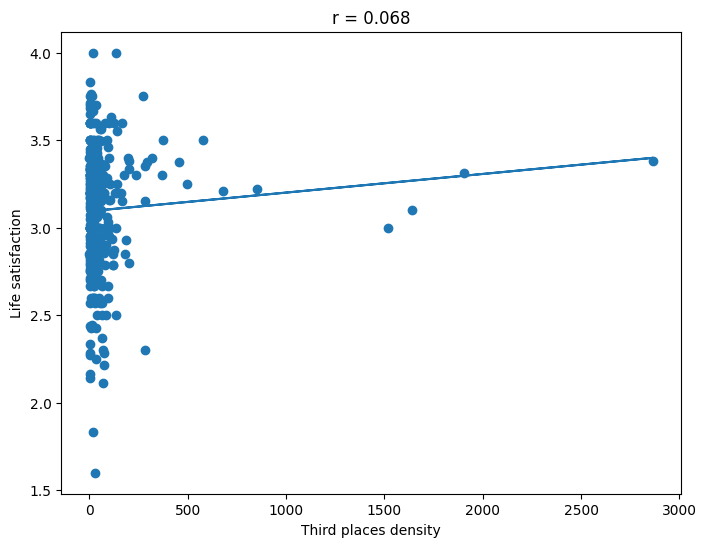

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# =========================================================
# COLAPSAR SATISFACCIÓN A NIVEL CIUDAD
# =========================================================

city_life = (
    df24
    .groupby("CIUDAD", as_index=False)["life_satisfaction"]
    .mean()
)

# agregar label ciudad
city_life["city"] = city_life["CIUDAD"].map(ciudad_labels)

# =========================================================
# MERGE CON THIRD PLACES
# =========================================================

df_plot = city_life.merge(
    df_third_places,
    left_on="city",
    right_on="city",
    how="inner"
)

# limpiar missings
df_plot = df_plot.dropna(
    subset=["life_satisfaction", "third_places_density"]
)

# =========================================================
# PEARSON
# =========================================================

r, p = pearsonr(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-value = {p:.5f}")

# =========================================================
# SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"]
)

# línea de tendencia
z = np.polyfit(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"],
    1
)

pfit = np.poly1d(z)

plt.plot(
    df_plot["third_places_density"],
    pfit(df_plot["third_places_density"])
)

plt.xlabel("Third places density")
plt.ylabel("Life satisfaction")
plt.title(f"r = {r:.3f}")

plt.show()

In [ ]:
df_third_places[
    df_third_places["third_places_density"] > 1
][[
    "city",
    "country",
    "tamciud",
    "third_places",
    "third_places_density"
]].sort_values("third_places_density", ascending=False)

,city,country,tamciud,third_places,third_places_density
183,CL: Metropolitana-El Bosque,Chile,1,542,6.900958
101,CR: San Jose-San Jose,Costa Rica,3,1857,2.627118
98,CR: San Jose-Goicoechea,Costa Rica,3,1833,2.593165
114,CR: Heredia-Heredia,Costa Rica,3,970,1.372269
102,CR: San Jose-Tibas,Costa Rica,4,1700,1.352817
100,CR: San Jose-Moravia,Costa Rica,4,1491,1.186500
95,CR: San Jose-Curridabat,Costa Rica,4,1447,1.151486
99,CR: San Jose-Montes de Oca,Costa Rica,4,1425,1.133979
